A script that takes in netCDF data and creates habitability globe plots

In [32]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

Choose the planetary parameter you want to test

In [33]:
# ROTATION
rot_earth = 7.2921159e-5
rot_rate = np.arange(0.1,2.1,0.1)
print(rot_rate)

# AXIAL TILT
at_arr = np.arange(-45,55,10)
print(at_arr)

# SOLAR FLUX 
sf_array = np.arange(800,1900,100)
print(sf_array)

# ATMOSPHERIC THICKNESS
atm_arr = np.arange(50000,160000,10000)
print(atm_arr)

# GRAVITY
g_arr = np.arange(10,110,10)
print(g_arr)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]
[-45 -35 -25 -15  -5   5  15  25  35  45]
[ 800  900 1000 1100 1200 1300 1400 1500 1600 1700 1800]
[ 50000  60000  70000  80000  90000 100000 110000 120000 130000 140000
 150000]
[ 10  20  30  40  50  60  70  80  90 100]


Open your desired dataset - uncomment your desired dataset

In [ ]:
# ROTATION
ds = xr.open_dataset("rotation_trials/output_rot_11.nc")

# AXIAL TILT
#ds =  xr.open_dataset("axial_tilt_trials_2yr/output_rot_9.nc")

# SOLAR FLUX
#ds =  xr.open_dataset("solar_flux_trials/output_rot_11.nc")

# ATMOSPHERIC THICKNESS
#ds = xr.open_dataset("atmos_trials/output_rot_11.nc")

# GRAVITY
#ds = xr.open_dataset("grav_trials/output_rot_10.nc")

Calculating your habitability fraction

In [35]:
# Extract desired variables
st = ds["st"].isel(soil_layer=0)
sm = ds["sm"].isel(soil_layer=0)
tsurf = ds["tsurf"]

# Create masked dataframes
da_st = st.mean(dim="time")
da_sm = sm.mean(dim="time")
da_tsurf = tsurf.mean(dim="time")

# Create a land mask 
land = da_sm > 1e-6

# Creating habitability masks
hab_sm = (da_sm >= 0.1) & land
hab_st = (da_st >= 0) & (da_st <= 48) & land
hab_tsurf = (da_tsurf >= 0) & (da_tsurf <= 48) & land

# latitude-based area weights
lat = sm.lat
weights = np.cos(np.deg2rad(lat))
weights = weights.where(np.isfinite(weights), 0)

# area-weighted habitability (%)
hab_fraction_st = ((hab_st * weights).sum() / (land * weights).sum()) * 100
hab_fraction_st = hab_fraction_st.item()

hab_fraction_sm = ((hab_sm * weights).sum() / (land * weights).sum()) * 100
hab_fraction_sm = hab_fraction_sm.item()

hab_fraction_tsurf = ((hab_tsurf * weights).sum() / (land * weights).sum()) * 100
hab_fraction_tsurf = hab_fraction_tsurf.item()

print(hab_fraction_st, hab_fraction_sm, hab_fraction_tsurf)

53.977280080911946 75.00634711327652 70.1693559183802


Plot your habitability

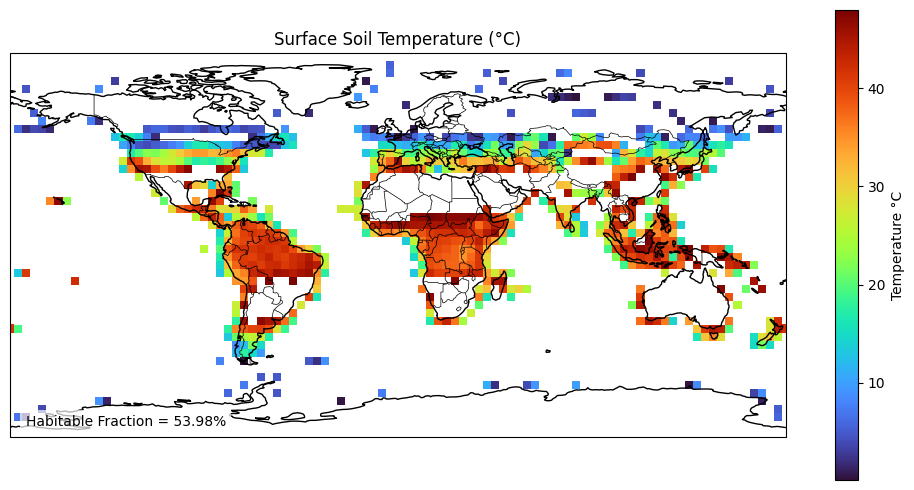

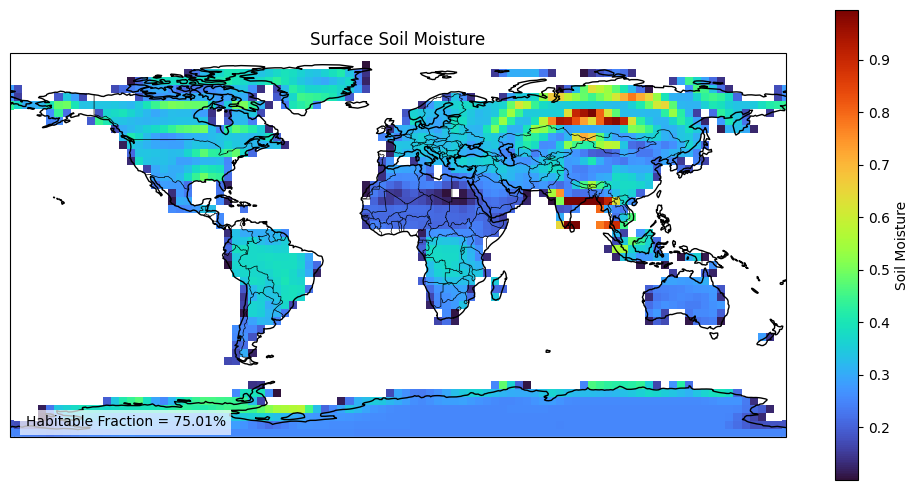

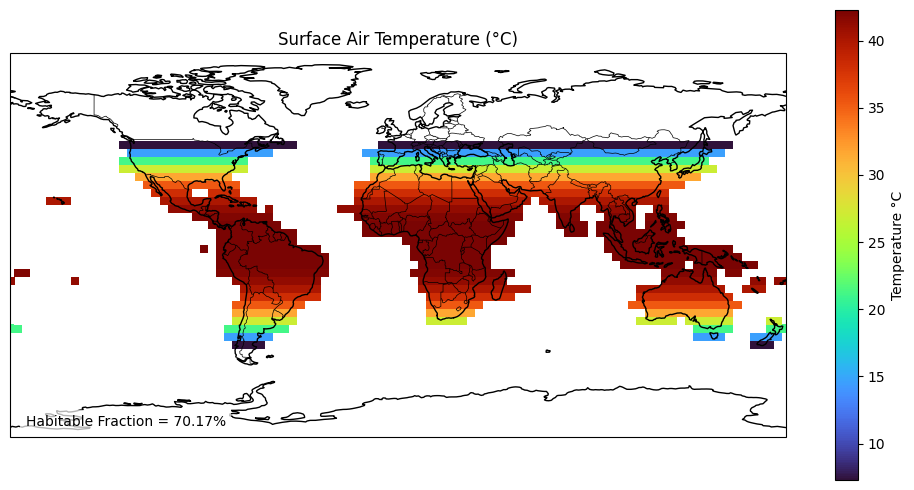

In [36]:


# Creating figures
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da_st.where(hab_st).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_st:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("rotation_trials/rot1.0_st.png")

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da_sm.where(hab_sm).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Soil Moisture"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Moisture")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_sm:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("rotation_trials/rot1.0_sm.png")

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da_tsurf.where(hab_tsurf).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_tsurf:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("rotation_trials/rot1.0_tsurf.png")
